## Анализ и прогнозирование временных рядов методами искусственного интеллекта

### **Практическая работа 3. Поиск аномалий во временных рядах.**


#### **3.1 Поиск диссонансов с помощью алгоритма HotSAX**

##### 3.1.1 Загрузка и подготовка данных

В данной будет использоваться временной ряд, состоящий из показаний акселерометра. 
Анализируемый временной ряд, описывает две активности человека - бег и шаг.


In [1]:
import sys
print(sys.executable)

/Users/mikhail/Developer/SUSU.PE-TIME.SERIES.COURSE-2026/.venv/bin/python


In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from time import time
import pandas as pd
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

Matplotlib is building the font cache; this may take a moment.


In [3]:
#fixme: Путь
dataset_dir_path = Path('datasets')
data_path = dataset_dir_path/'walk_run.txt'
walk_run = np.loadtxt(data_path)[3000:4000]
data = walk_run
size_sub = 50

В середине временного ряда происходит смена активности (бег заменяет шаг). Нетипичным поведением, которое мы могли бы назвать диссонансами в данном ряде выступает небольшой участок между активностями, когда человек плавно увеличивает скорость шага до бега. В ходе данной работе наша задача выделить с помощью различных алгоритмов границы нашего диссонанса.

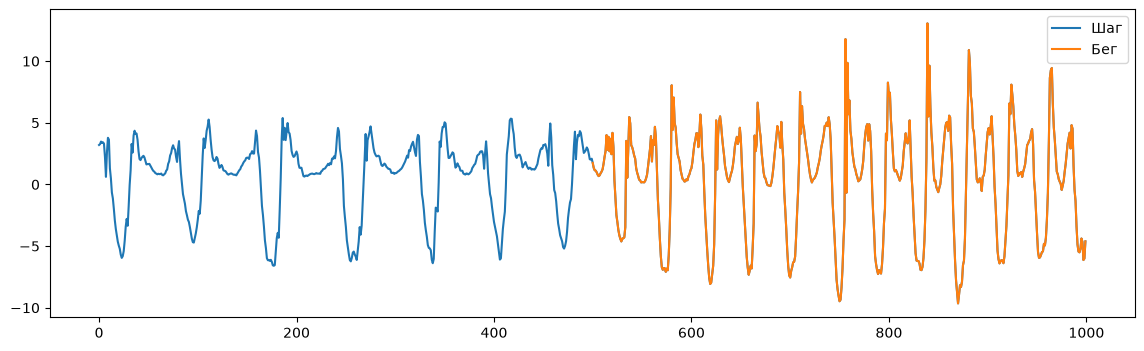

In [4]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.plot(np.arange(data.shape[0]//2,data.shape[0]),data[data.shape[0]//2:],label='Бег')
plt.legend()

In [5]:
result={}
times={}

##### 3.1.2 Реализация полного перебора

Приводится пример кода для нахождения топ 5 диссонансов с помощью реализации полного беребора.
Вам необходимо добавить код для сбора времени обработки данных.

In [6]:
from modules.saxpy.discord import find_discords_brute_force
start = time()
discords_brute_force= np.stack(find_discords_brute_force(data[:], 50, 5))
end = time()
result['Brute Force'] = discords_brute_force
times['Brute Force'] = end - start

##### 3.1.3 HotSAX

Используя [реализацию](https://github.com/seninp/saxpy/blob/master/saxpy/hotsax.py) найдите топ 5 диссонансов ряда.
Произведите замер времени работы.

In [7]:
from modules.saxpy.hotsax import find_discords_hotsax

start = time()
discords_hotsax = np.stack(find_discords_hotsax(data, 50, 5))
end = time()
result['HotSAX'] = discords_hotsax
times['HotSAX'] = end - start
pd.DataFrame({'Время, с': times})

,"Время, с"
Brute Force,29.797469
HotSAX,0.621361


##### 3.1.4 Визаулизация

Вам необходимо реализовать код позволяющий:
1. Вывести на одном графике ряд и его диссонансы
2. Столбчатую диаграмму времени работы обоих алгоритмов
   
Постройте графики для обоих алгоритмов и сравните полученные результаты.

Пример графика:

![first_graf](pics/fig_ex_1.png)

**Результат запуска.** Полный перебор и HotSAX нашли одинаковые начала окон: 477, 412, 195, 577 и 278. Время поиска составило 29,7975 и 0,6214 с соответственно; HotSAX быстрее примерно в 48 раз. Первые два окна находятся рядом с переходом между активностями. При фиксированном topK=5 в результат также попадают необычные по форме фрагменты вне перехода.

In [8]:
def plot_discords(data: np.ndarray, indices: np.ndarray, lengths: int | np.ndarray,
                  title: str, ax: plt.Axes | None = None) -> plt.Axes:
    """Показать ряд и выделить найденные подпоследовательности."""
    if ax is None:
        _, ax = plt.subplots(figsize=(14, 4))
    ax.plot(data, linewidth=0.8)
    for index, length in zip(indices, np.broadcast_to(lengths, len(indices))):
        index, length = int(index), int(length)
        ax.axvspan(index, index + length, color='red', alpha=0.15)
        ax.plot(np.arange(index, index + length), data[index:index + length], color='red')
    ax.set(title=title, xlabel='Индекс', ylabel='Значение')
    return ax

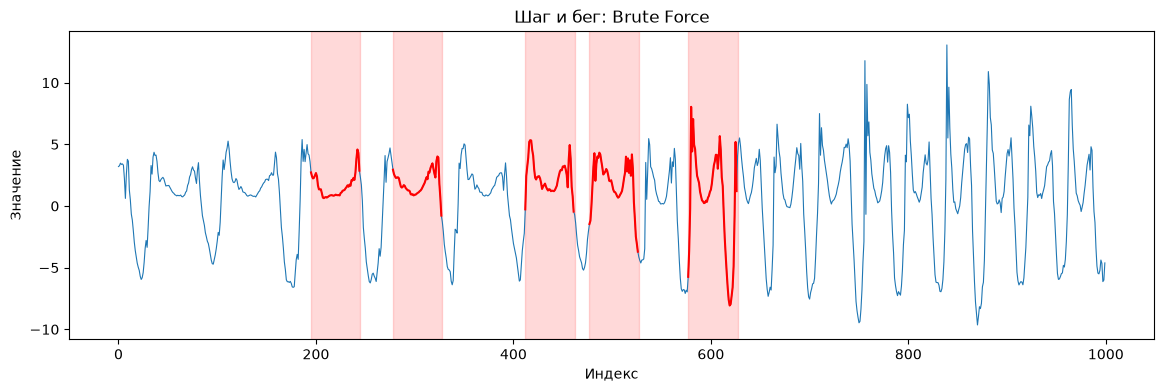

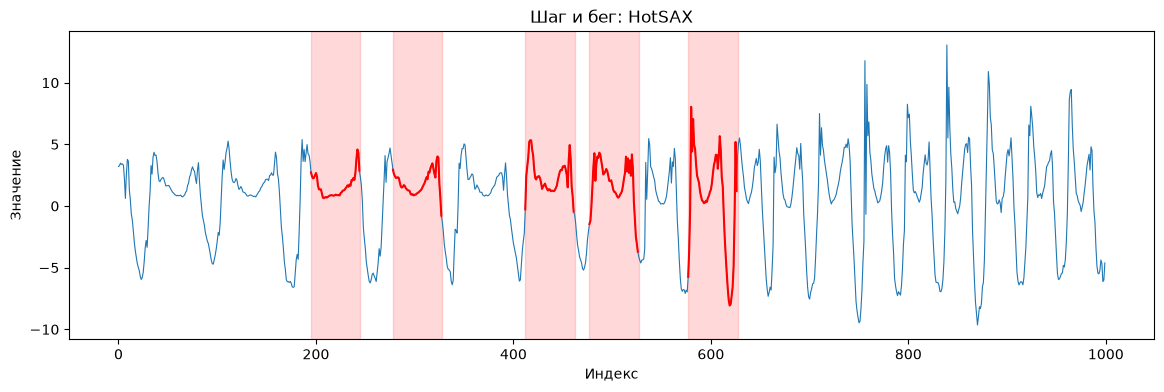

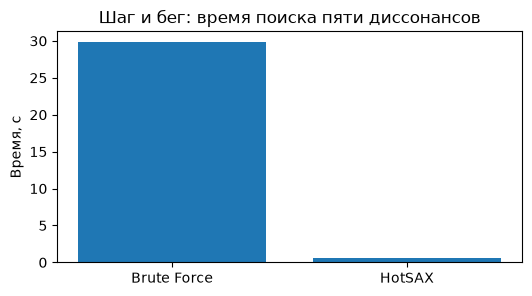

In [9]:
from matplotlib.patches import Rectangle

for method, discords in result.items():
    plot_discords(walk_run, discords[:, 0], size_sub, f'Шаг и бег: {method}')
plt.figure(figsize=(6, 3))
plt.bar(times.keys(), times.values())
plt.ylabel('Время, с')
plt.title('Шаг и бег: время поиска пяти диссонансов')
plt.show()

##### 3.1.5 Такси NY

Произведите поиск диссонансов с помощью обоих алгоритмов на наборе данных, содержащим информацию о среднем числе пассажиров в NY. Отобразите найденные диссонансы обоими алгоритмами. 

**Результат запуска.** Оба метода нашли начала 1910, 3120, 3183, 3237 и 963. Полный перебор занял 962,6212 с, HotSAX — 2,4880 с: ускорение около 387 раз. На графике выделяются необычный высокий пик около индекса 1950 и изменения суточной формы около индексов 3120–3280.

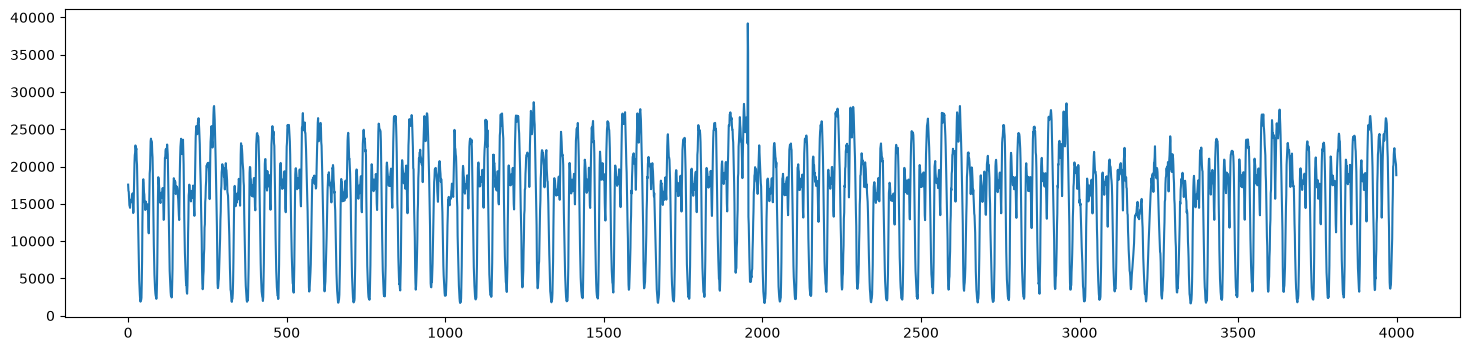

In [10]:
nyc_taxi = pd.read_csv(dataset_dir_path/'nyc_taxi.csv',index_col=0).values[4000:8000,0].astype(np.float64)
fig = plt.figure(figsize=(18, 4))
plt.plot(nyc_taxi)

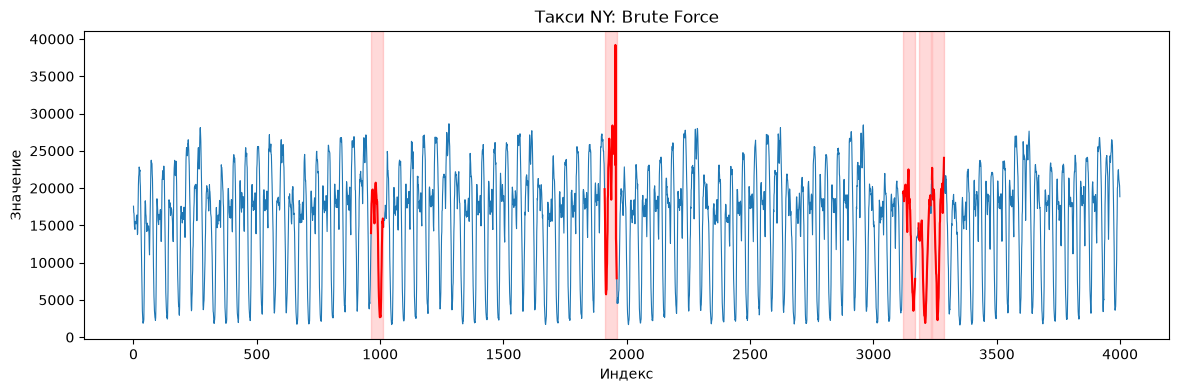

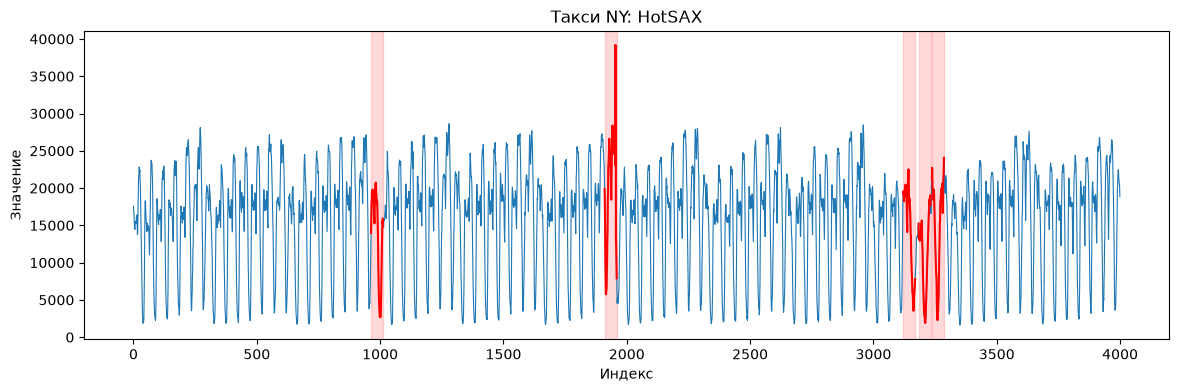

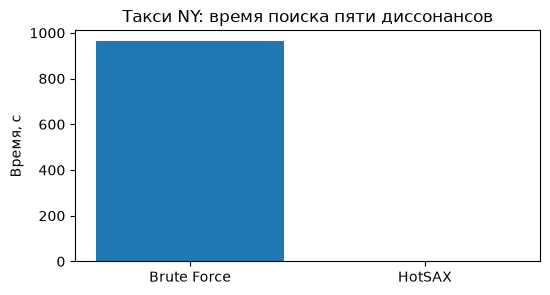

,"Время, с"
Brute Force,962.621219
HotSAX,2.487962


In [11]:
taxi_result = {}
taxi_times = {}
for method, finder in [('Brute Force', find_discords_brute_force), ('HotSAX', find_discords_hotsax)]:
    start = time()
    taxi_result[method] = np.stack(finder(nyc_taxi, size_sub, 5))
    taxi_times[method] = time() - start
    plot_discords(nyc_taxi, taxi_result[method][:, 0], size_sub, f'Такси NY: {method}')
plt.figure(figsize=(6, 3))
plt.bar(taxi_times.keys(), taxi_times.values())
plt.ylabel('Время, с')
plt.title('Такси NY: время поиска пяти диссонансов')
plt.show()
pd.DataFrame({'Время, с': taxi_times})

#### **3.2 Поиск диссонансов с помощью алгоритма DRAG**

In [12]:
from importlib.metadata import version
print('stumpy:', version('stumpy'))

stumpy: 1.11.1


In [13]:
import stumpy
from stumpy import core, config
from stumpy.scrump import _prescrump


/Users/mikhail/Developer/SUSU.PE-TIME.SERIES.COURSE-2026/.venv/lib/python3.12/site-packages/stumpy/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Как мы помним из лекций:

**Диапазонный диссонанс** – подпоследовательность ряда, расстояние от которой до ее ближайшего соседа не ниже заданного порога. 

Основными параметрами при поисках диссонансов являются:
- $m$ - длина диссонанса
- $r$ - пороговое значение расстояния подпоследовательности ряда, до его ближайшего соседа


In [14]:
from modules.drag import find_candidates, DRAG


Для поиска диссонансов в данной части практической работы мы воспользуемся алгоритмом **DRAG (Discord Range Aware Gathering)**.
Для начала воспользуемся данным алгоритмом, чтобы найти диссонансы в наборе данных содержащем активность человека.

In [15]:
data = walk_run

Длину искомого диссонанса, как и для предыдущих алгоритмов, мы установим равно 50 точек.
Пороговое значение мы установим равным большим, чтобы узнать, как алгоритм отреагирует на большие значения данного параметра.

In [16]:
m = 50 
r = 10
idxs, _, _ = DRAG(data,m,r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 0


Как вы можете видеть мы установили слишком большое пороговое значение, алгоритму не удалось выделить ни одного диссонанса. Попробуем уменьшить пороговое значение до 1, чтобы улучшить результат. 

In [17]:
m = 50 
r = 1
idxs, _, _ = DRAG(data, m, r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 50


При такой комбинации параметров, улучшить ситуацию не получилось. Алгоритм выделил слишком большое количество диссонансов, часть которых является ложными диссонансами и не будут информативными для нас.

Произведите подобные эксперименты с набором данных такси NY. Постройте графики демонстрирующие найденные диссонансы. Пример Графика:
![second-graph](pics/fig_ex_2.png)

r=10: 0 диссонансов


r=1: 42 диссонансов


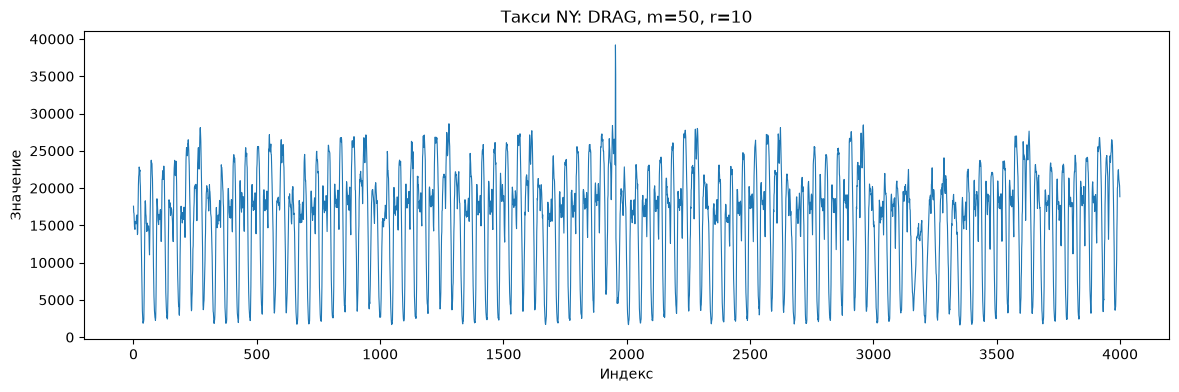

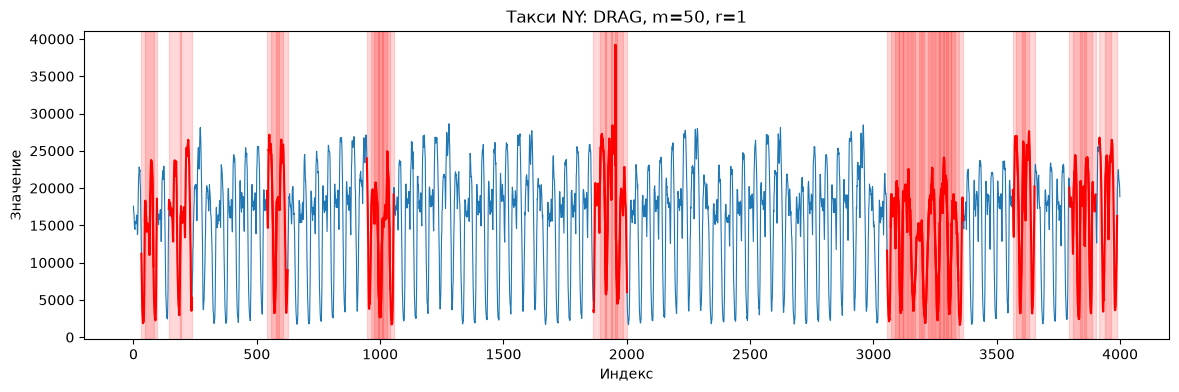

In [18]:
taxi_drag = {}
for threshold in [10, 1]:
    taxi_drag[threshold] = DRAG(nyc_taxi, 50, threshold)
    print(f'r={threshold}: {len(taxi_drag[threshold][0])} диссонансов')
    plot_discords(nyc_taxi, taxi_drag[threshold][0], 50, f'Такси NY: DRAG, m=50, r={threshold}')
plt.show()

Чтобы разобраться, почему так происходит и как работает данный алгоритм, ниже мы реализуем все этапы алгоритма DRAG.

Как мы помним из лекций алгоритм DRAG содержит два этапа:

1. Отбор - За одно сканирование ряда сформировать множество кандидатов в диссонансы.
2. Очистка - За одно сканирование ряда отбросить кандидатов, которые являются ложными диссонансами.

##### 3.2.1 Отбор кандидатов

Первым этапом обработки данных является отбор множества потенциальных кандидатов. Мы выбираем из всего множества подпоследовательностей ряда такие, для которых расстояние до правых ближайших соседей больше параметра $r$.

In [19]:
#выбирем более реальное значение для порога
r = 3

In [20]:
T, M_T, Σ_T = core.preprocess(data, m)
#формируем массив длинной равной длине  исходного ряда - m + 1, 
#элемент массива является истинным, 
#в том случае если подпоследовательность является потенциальным кандидатом
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
#находим индексы потенциальных кандидатов
cand_index = np.flatnonzero(is_cands)

In [21]:
print(f'{len(cand_index)} {len(cand_index)/len(data)*100} %')

113 11.3 %


Во время отбора кандидатов нам удалось выделить около 113 подпоследовательностей(около 11.3%), которые мы бы могли назвать потенциальными диссонансами.
Это большой процент, который не может нас устраивать как конечный результат.
Если посмотреть на рисунок ниже, мы увидим, что большая часть потенциальных диссонансов расположена в районе смены активности. 
К сожалению пресутсвуют и ложные диссонансы, которые случайным образом попали в данный список.

**Результат запуска.** Получено 113 кандидатов — 11,3% длины ряда (113 из 951 возможного окна). Отбор ещё сохраняет соседние окна и фрагменты вне перехода; требуется очистка.

Сформируйте график найденных диссонансов

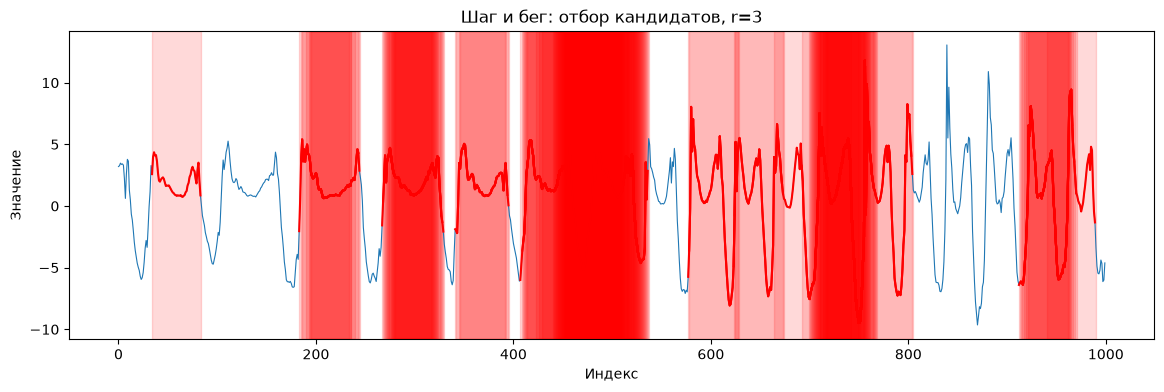

In [22]:
plot_discords(data, cand_index, m, f'Шаг и бег: отбор кандидатов, r={r}')
plt.show()

##### 3.2.2 Очистка кандидатов
Как уже упоминалось выше, 11.3% слишком большой процент диссонансов.
Для уменьшения числа потенциальных кандидатов произведем очистку от ложных диссонансов, путем сравнения расстояния до левых ближайших соседей потенциальных диссонансов с порогом $r$.


In [23]:
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)
cands = np.flatnonzero(is_cands)

In [24]:
len(cands)/len(data)*100

2.9000000000000004

Сформируйте график найденных диссонансов

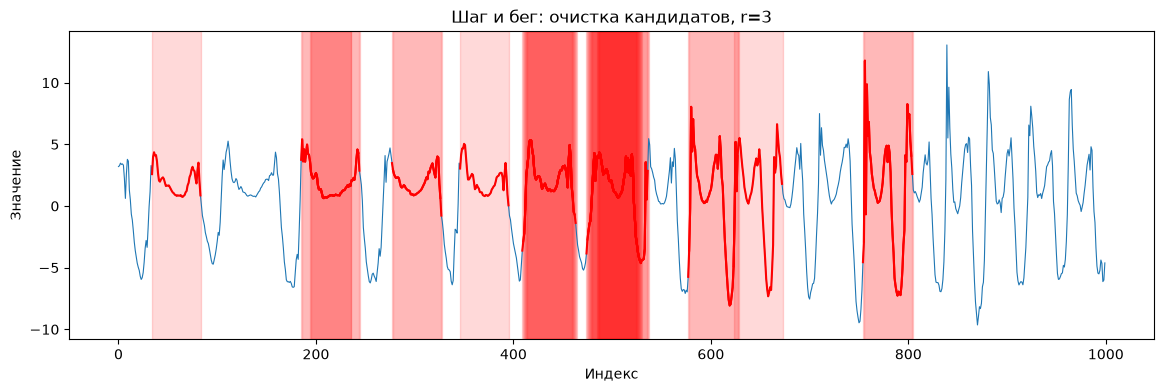

In [25]:
plot_discords(data, cands, m, f'Шаг и бег: очистка кандидатов, r={r}')
plt.show()

Нам удалось сократить число диссонансов до 2.9%. Если проанализировать рисунок, то можно заметить, что большая их часть является тривиальными повторениями подпоследовательности в области смены активности. На следующем шаге избавимся от них.

**Результат запуска.** После очистки осталось 29 окон — 2,9% длины ряда. Исключение тривиальных повторений далее оставляет 9 диссонансов, или 0,9%. При r=3 среди них ещё есть окна вне смены активности.

In [26]:
from modules.drag import refine_candidates
discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)
len(discords_idx)/len(data)*100

0.8999999999999999

Сформируйте график найденных диссонансов

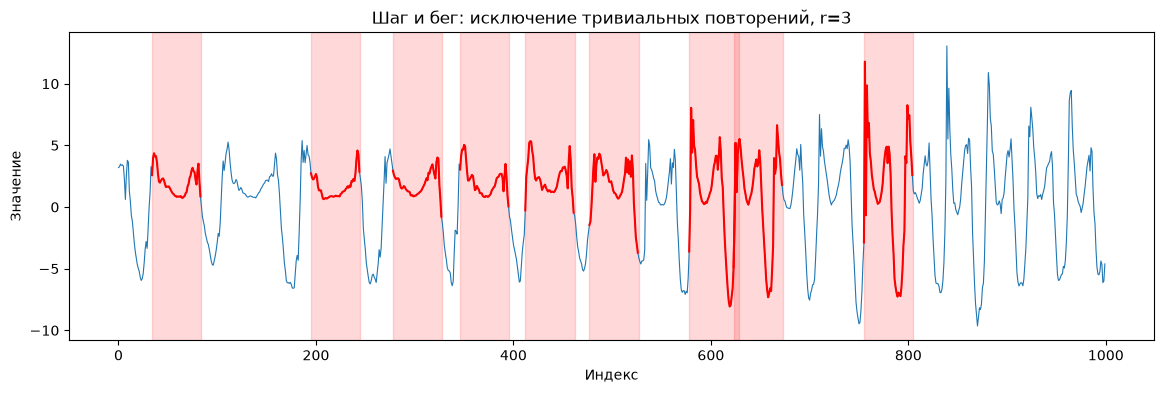

In [27]:
plot_discords(data, discords_idx, m, f'Шаг и бег: исключение тривиальных повторений, r={r}')
plt.show()

##### 3.2.3 Подбор параметров

Реализуйте перебор параметров $m$ и $r$. Подберете параметры таким образом, чтобы алгоритм обнаружил только те диссонансы, которые связаны со сменой активности. Сделайте вывод о том, как эти параметры влияют на качество работы модели.
Подберите оптимальные параметры алгоритма для набора данных такси NY. 
Визуализируйте результаты для разных комбинаций. Сделайте выводы.


**Результат запуска.** Перебраны m=25, 50, 75 и r=1, 3, 5, 10. Для акселерометра выбираем m=75, r=5: найден один фрагмент [470, 545), охватывающий смену активности. При m=50, r=5 найдены два близких к переходу окна с началами 477 и 412. Малый r=1 даёт много фрагментов, а r=10 не даёт результатов; при m=25 уже r=3 слишком велик.

Для такси выбираем m=50, r=3: получены начала 1910, 1952, 3120 и 1934, сосредоточенные в двух необычных областях ряда. Окно 50 охватывает примерно суточный цикл. При r=1 найдено 42 фрагмента, при r=5 — ни одного. Вариант m=75, r=5 оставляет только окно с началом 3118 и пропускает высокий пик около 1950. Выбор сделан визуально: разметки истинных аномалий в задании нет.

Увеличение r сокращает число кандидатов. Длина m определяет форму сравниваемого фрагмента и масштаб расстояния, поэтому один порог нельзя без проверки переносить между длинами и наборами данных.

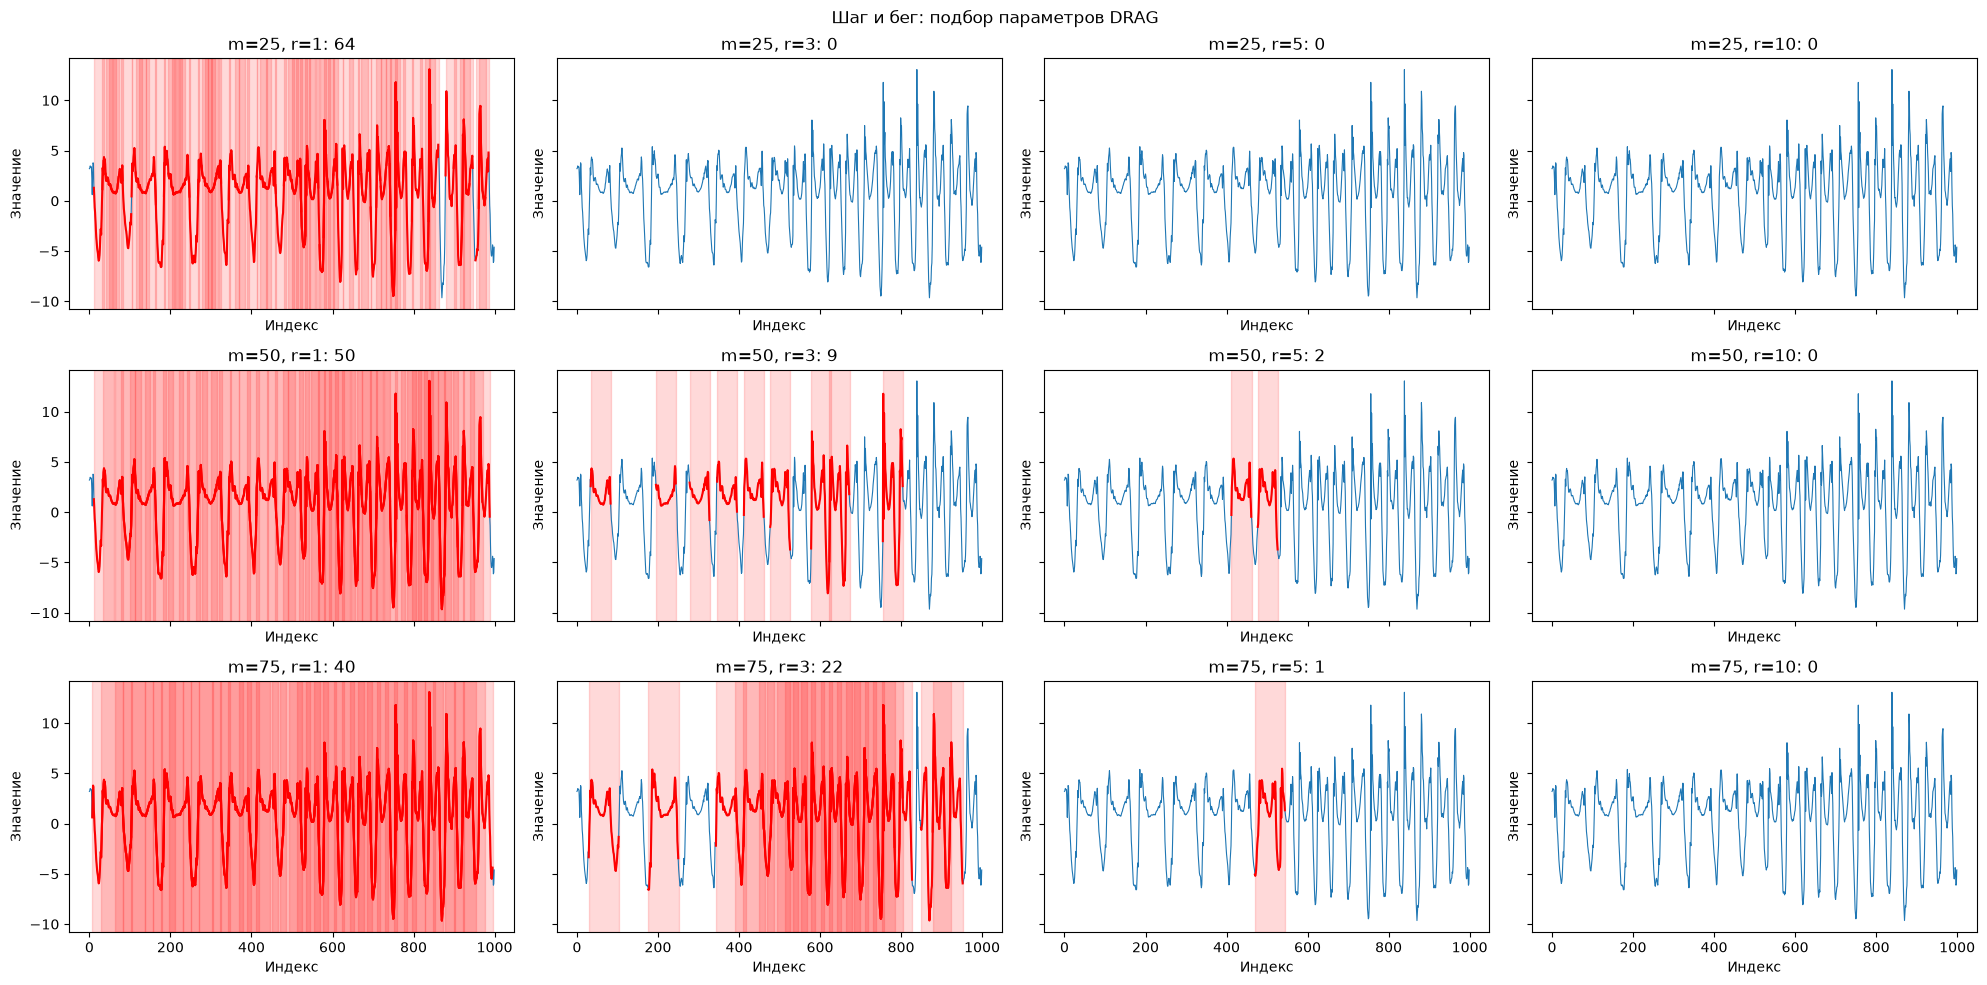

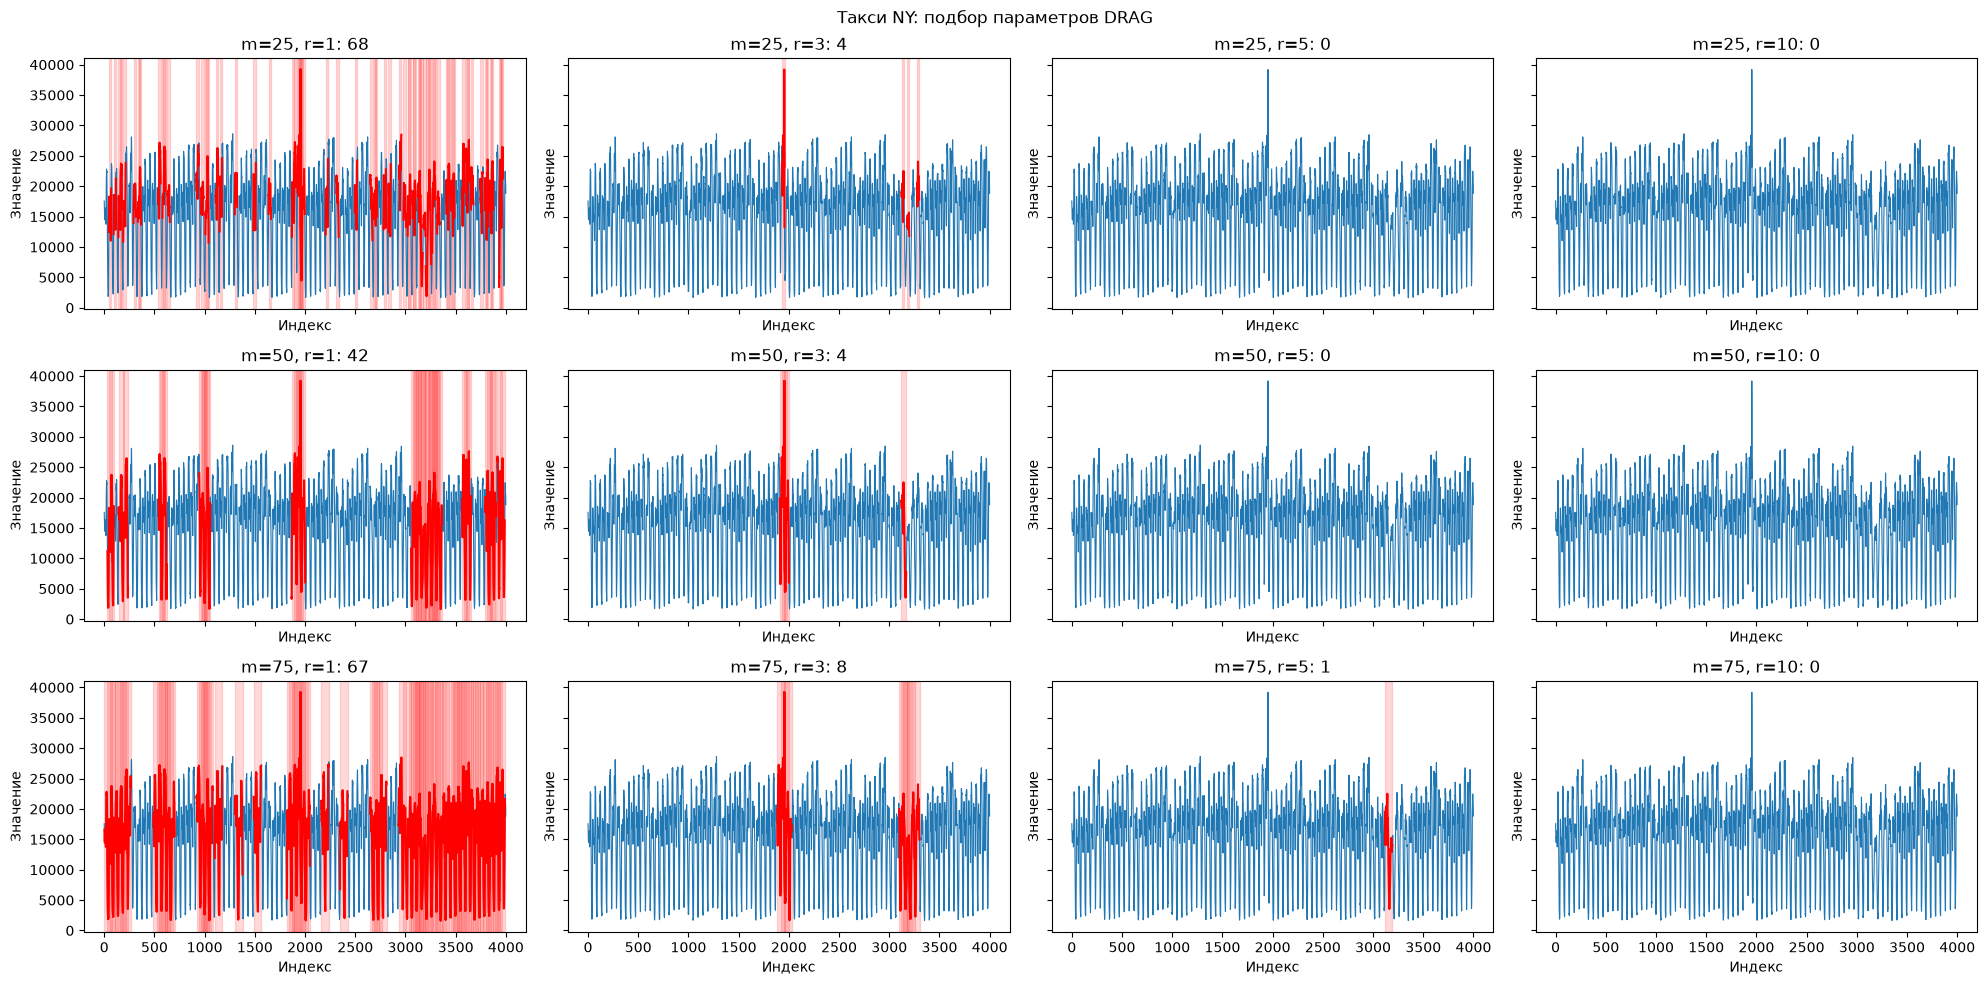

In [28]:
drag_grid = {}
for name, series in [('Шаг и бег', walk_run), ('Такси NY', nyc_taxi)]:
    fig, axes = plt.subplots(3, 4, figsize=(20, 10), sharex=True, sharey=True)
    for row, window in enumerate([25, 50, 75]):
        for column, threshold in enumerate([1, 3, 5, 10]):
            discords = DRAG(series, window, threshold)
            drag_grid[name, window, threshold] = discords
            plot_discords(series, discords[0], window,
                          f'm={window}, r={threshold}: {len(discords[0])}', axes[row, column])
    fig.suptitle(f'{name}: подбор параметров DRAG')
    plt.tight_layout()
    plt.show()

#### **3.3 Поиск диссонансов с помощью алгоритма Merlin**

Как мы уже выяснили подбирать параметры для DRAG простым перебором не очень удобно. Для оптимизации данного процесса в статье [1] был предложен алгоритм Merlin для оптимального поиска подходящего порогового значения.

Условно мы можем разделить поиск диссонансов на три шага:

1. Поиск диссонансов минимальной длинны $minL$. На данном шаге $r = 2\sqrt{minL}$.
2. Поиск диссонансов следующих четырех длин. На данном шаге $r = 0.99 \cdot nndist_{m-1}$. Где $nndist_{m-1}$ - расстояние до ближайшего соседа предыдущего найденного диссонанса.
3. Поиск диссонансов всех 
оставшихся дли. $r = \mu - 2 \sigma$. Средние значение и стандартное отклонение вычисляются из расстояний 5 предыдущих диссонансов. н

[1] Nakamura T., Imamura M., Mercer R., Keogh E.J. MERLIN: parameter-free discovery of arbitrary length anomalies in massive time series archives. 20th IEEE Int. Conf. on Data Mining, ICDM 2020, Sorrento, Italy, November 17-20, 2020. pp. 1190-1195. IEEE (2020). https://doi.org/10.1109/ICDM50108.2020.00147

##### 3.3.1 Поиск диссонансов минимальной длинны

Вспомнил последовательность действий первого шага алгоритма:
![merlin-part-first](pics/first_part.png)

В данной работе мы внесем небольшое изменение, мы будем считать, что подпоследовательность может быть диссонансом только в том случае, если больше 75% точек, не входят в состав других диссонансов. 

In [29]:
T = walk_run
m = 50
# сформируем массив метод для потенциальных кандидатов в диссонансы.
# после каждого найденного диссонанса, 
# мы будем исключать окружающие его подпоследовательности из числа потенциальных кандидатов,
# путем замены значений их меток на false
excl_zone = int(np.ceil(m / 4))
include = np.ones(len(T)-m+1, dtype=bool)
# Количество диссонансов, которые мы будем искать
topK = 10

occupied = np.zeros(len(T), dtype=bool)

In [30]:
dis_idx = -np.ones((topK))
dis_nnDist = -np.ones((topK))
dis_nn_idx = np.full((topK),-np.inf)
#первое прближение r
r = 2*np.sqrt(m)
minL = m
maxL = int(m+np.ceil(m*0.1))
#количество найденных диссонасов
cound_find_dis = 0

while dis_nnDist[cound_find_dis-1]<0 and cound_find_dis<topK:
    result = DRAG(data=T,m=minL,r=r, include =include)
    for diss, nnDist, nn in zip(*result):
        if occupied[diss:diss + minL].mean() >= 0.25:
            continue
        occupied[diss:diss + minL] = True
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        #исключаем окружающие найденный диссонас 
        #подпоследовательности и числа потенциальных диссонасов
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis+=1
        if cound_find_dis>=topK:
            break
    r*=0.5

In [31]:
maxL

55

In [32]:
print('Количество найденных на первом этапе диссонансов:', cound_find_dis)

Количество найденных на первом этапе диссонансов: 2


На первом шаге нам удалось выделить 2 диссонанса из 10 требуемых. 
Реализуйте, оставшиеся шаги алгоритма, чтобы найти оставшиеся диссонансы. 

![merlin-part-first](pics/second_part.png)


**Результат запуска.** Первый этап с условием о более чем 75% новых точек действительно выделил два окна: [477, 527) и [412, 462). Далее порог подбирается для следующих длин по приведённому псевдокоду.

In [33]:
def merlin(data: np.ndarray, minL: int, maxL: int, topK: int) -> pd.DataFrame:
    """Найти диссонансы разных длин с тремя этапами выбора порога MERLIN."""
    discords = []
    occupied = np.zeros(len(data), dtype=bool)
    nn_distances = []
    for length in range(minL, maxL + 1):
        if length == minL:
            threshold = 2 * np.sqrt(minL)
        elif length <= minL + 4:
            threshold = 0.99 * nn_distances[-1]
        else:
            sigma = np.std(nn_distances[-5:])
            threshold = np.mean(nn_distances[-5:]) - 2 * sigma
        include = np.convolve(occupied.astype(int), np.ones(length, dtype=int), 'valid') < 0.25 * length
        candidates = DRAG(data, length, threshold, include)
        while not candidates[0]:
            if length == minL:
                threshold *= 0.5
            elif length <= minL + 4:
                threshold *= 0.99
            else:
                threshold -= sigma
            candidates = DRAG(data, length, threshold, include)
        accepted_distances = []
        for index, distance, neighbor in zip(*candidates):
            if len(discords) == topK:
                break
            if occupied[index:index + length].mean() >= 0.25:
                continue
            discords.append((index, length, distance, neighbor))
            occupied[index:index + length] = True
            accepted_distances.append(distance)
        nn_distances.append(min(accepted_distances))
        if len(discords) == topK:
            break
    return pd.DataFrame(discords, columns=['Начало', 'Длина', 'Расстояние', 'Ближайший сосед'])

Найдите диссонансы набора такси NY. Визуализируйте найденные диссонансы для обоих наборов данных, сравните с результатами остальных методов. 


**Результат запуска.** Для каждого ряда найдено по 10 диссонансов. У акселерометра встречаются все длины от 50 до 55, у такси — от 50 до 54. В обоих случаях новые окна удовлетворяют условию о более чем 75% точек вне ранее найденных диссонансов.

MERLIN сохранил области, найденные полным перебором и HotSAX, и добавил другие фрагменты при увеличении числа результатов до 10 и изменении длины. Он избавляет от ручного подбора r для каждой длины, но фиксированное число результатов не означает, что все они относятся к одному переходу активности. Для выделения только перехода на акселерометре наиболее наглядным оказался DRAG с m=75, r=5. У готовых реализаций разные зоны исключения: полный перебор и HotSAX исключают перекрывающиеся окна, DRAG использует ceil(m/4); поэтому их списки могут различаться.

,Начало,Длина,Расстояние,Ближайший сосед
0,477,50,5.881009,701
1,412,50,5.327043,346
2,195,51,3.438768,112
3,575,52,3.322840,529
4,31,53,3.258793,343
5,343,53,3.258793,31
6,755,54,3.240810,796
7,623,54,3.238178,754
8,109,55,3.024128,272
9,273,55,2.939377,110


,Начало,Длина,Расстояние,Ближайший сосед
0,1910,50,3.526815,2918
1,1952,50,3.489196,608
2,3120,50,3.402332,3219
3,3183,50,2.642041,3234
4,3237,50,2.229228,3326
5,3280,50,1.820873,2272
6,963,51,1.664943,1298
7,3912,52,1.561241,3576
8,3079,53,1.481413,2694
9,1859,54,1.491722,2530


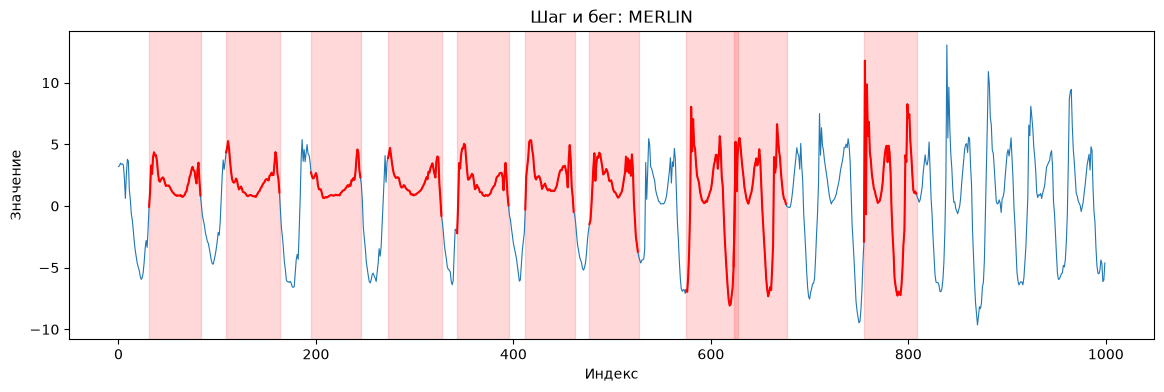

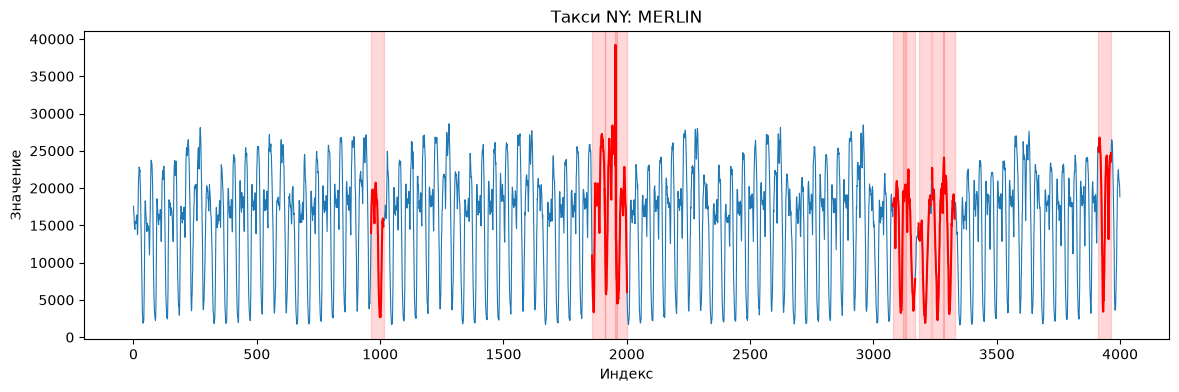

In [34]:
merlin_result = {}
for name, series in [('Шаг и бег', walk_run), ('Такси NY', nyc_taxi)]:
    merlin_result[name] = merlin(series, minL, maxL, topK)
    display(merlin_result[name])
    plot_discords(series, merlin_result[name]['Начало'], merlin_result[name]['Длина'], f'{name}: MERLIN')
plt.show()